In [1]:
pip install pandas nltk matplotlib

  Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   -------- ------------------------------- 0.5/2.3 MB 3.6 MB/s eta 0:00:01
   ---------------------- ----------------- 1.3/2.3 MB 3.6 MB/s eta 0:00:01
   ----------------------------------- ---- 2.1/2.3 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 3.6 MB/s  0:00:00
Using cached kiwi


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt

In [3]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Maksym\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Maksym\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Maksym\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
data = pd.read_csv("reviews.csv")

In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

In [6]:
data["cleaned_review"] = data["review"].apply(clean_text)

In [7]:
stop_words = set(stopwords.words('english'))

In [8]:
all_tokens = []

In [9]:
for review in data["cleaned_review"]:
    tokens = word_tokenize(review)

    filtered_tokens = [
        token for token in tokens
        if token not in stop_words and len(token) >= 3
    ]

    all_tokens.extend(filtered_tokens)

In [10]:
word_freq = Counter(all_tokens)

In [11]:
top_15 = word_freq.most_common(15)

Топ 15 найчастіших слів:

product: 2
good: 2
service: 2
quality: 2
excellent: 2
amazing: 1
works: 1
perfectly: 1
really: 1
liked: 1
fast: 1
delivery: 1
packaging: 1
terrible: 1
customer: 1


<BarContainer object of 15 artists>

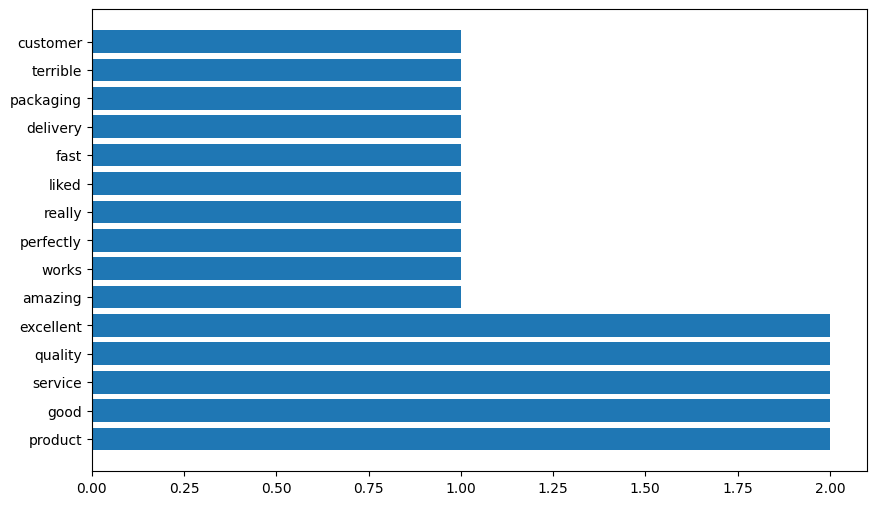

In [12]:
print("Топ 15 найчастіших слів:\n")

for word, count in top_15:
    print(f"{word}: {count}")

words = [word for word, count in top_15]
counts = [count for word, count in top_15]

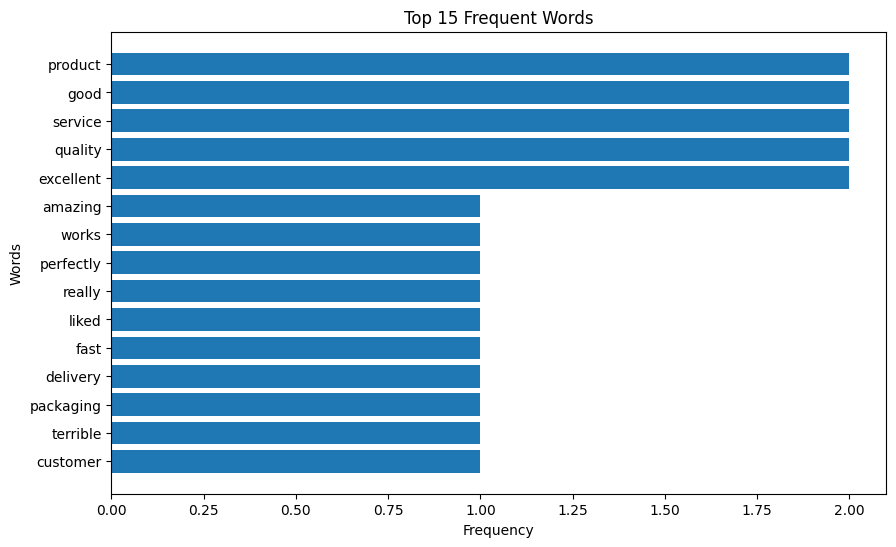


Графік збережено як 'feedback_word_freq.png'


In [14]:
plt.figure(figsize=(10, 6))
plt.barh(words, counts)

plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 15 Frequent Words")

plt.gca().invert_yaxis()

plt.savefig("feedback_word_freq.png")

plt.show()

print("\nГрафік збережено як 'feedback_word_freq.png'")